In [1]:
import pyphot
import numpy as np
from matplotlib import pyplot as plt

from astropy import units as u

In [2]:
from pyphot.svo import get_pyphot_filter

filter_lst = ['Euclid/VIS.vis', 'Euclid/NISP.Y', 'Euclid/NISP.J', 'Euclid/NISP.H']

filters = [get_pyphot_filter(filter) for filter in filter_lst]

Ell_sed = np.loadtxt('./inputs/SEDs/Ell13_template_norm.csv', unpack=True)

Ell_sed.shape, filters

((2, 1146),
 [Filter: Euclid_VIS.vis, <pyphot.phot.Filter object at 0x162fd9610>,
  Filter: Euclid_NISP.Y, <pyphot.phot.Filter object at 0x1038f8bf0>,
  Filter: Euclid_NISP.J, <pyphot.phot.Filter object at 0x103a191f0>,
  Filter: Euclid_NISP.H, <pyphot.phot.Filter object at 0x162fdab70>])

(0.4, 2.5)

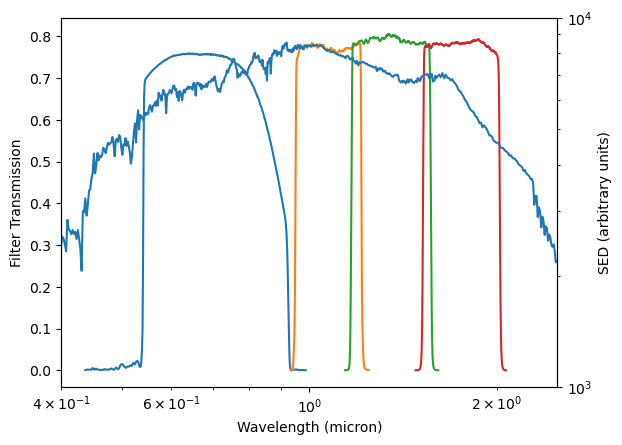

In [3]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

for f in filters:
    ax1.plot(f.wavelength.to(u.micron), f.transmit, label=f.name)

ax2.plot((Ell_sed[0]*u.AA).to(u.micron), Ell_sed[1]*Ell_sed[0], label='Ell13 SED')

ax1.set_xlabel('Wavelength (micron)')
ax1.set_ylabel('Filter Transmission')
ax2.set_ylabel('SED (arbitrary units)')

ax2.set_yscale('log')
ax1.set_xscale('log')

ax2.set_ylim(1e3, 1e4)

ax1.set_xlim(0.4, 2.5)

In [4]:
for f in filters:
    flux = f.get_flux(Ell_sed[0]*u.AA, Ell_sed[1]*u.erg/u.s/u.cm**2/u.AA)
    ab_mag = -2.5 * np.log10(flux.value) - f.AB_zero_mag
    print(flux, ab_mag, f.AB_zero_mag)

0.9553206709579248 erg / (Angstrom s cm2) -21.615643512821343 21.665270575350505
0.7451601360762405 erg / (Angstrom s cm2) -22.25275171318627 22.572127679835894
0.5179689402781151 erg / (Angstrom s cm2) -22.364694192896845 23.078934897154653
0.33676905659920603 erg / (Angstrom s cm2) -22.45985457549751 23.641524124705093


In [5]:
import pickle as pkl
import pandas as pd
from astropy.cosmology import FlatLambdaCDM

from create_images_real import augment_lens_main, augment_lens_point, augment_light

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

SED_paths = {'source': './inputs/SEDs/sed_rest_frame_star_forming.csv', 'lens': './inputs/SEDs/Ell13_template_norm.csv'}
    
with open("./inputs/base_class/main_1/kwargs.pkl", 'rb') as f:
    data = pkl.load(f)
    kwargs_params, kwargs_models, multiband_list = data['params'], data['models'], data['multiband_list']

deflector_file = "./inputs/is_this_right_1_deflector.csv"
source_file = "./inputs/is_this_right_1_source.csv"

deflector_augments = pd.read_csv(deflector_file)
source_augments = pd.read_csv(source_file)

zeropoints = np.array([25.74, 29.8, 30.0, 29.9])

for (deflector_row, source_row) in zip(deflector_augments.itertuples(index=False), source_augments.itertuples(index=False)):
    #augment_lens_main(kwargs_params, kwargs_models, multiband_list, deflector_row, source_row, SED_paths, zeropoints, cosmo)
    continue

In [6]:
angular_diameter_distance_deflector = cosmo.angular_diameter_distance(deflector_row[-1])   # in kpc
angular_diameter_distance_source = cosmo.angular_diameter_distance(source_row[-1])   # in kpc

deflector_rad = ((deflector_row[0] / angular_diameter_distance_deflector.to(u.kpc).value) * u.radian).to(u.arcsec).value
source_rad = ((source_row[0] / angular_diameter_distance_source.to(u.kpc).value) * u.radian).to(u.arcsec).value

system_rotation = deflector_row[6]

#print(f"Deflector rad (arcsec): {deflector_rad}, Source rad (arcsec): {source_rad}")

lens_m_to_l = kwargs_params['kwargs_lens'][0]['theta_E'] / kwargs_params['kwargs_lens_light'][0]['R_sersic']

# Augment lens and source light model parameters
kwargs_params['kwargs_lens_light'][0], vis_ab_mag_deflector, redshift_deflector = augment_light(kwargs_params['kwargs_lens_light'][0], deflector_row, deflector_rad)
kwargs_params['kwargs_source'][0], vis_ab_mag_source, redshift_source = augment_light(kwargs_params['kwargs_source'][0], source_row, source_rad, source=True, lens_rad_ratio=deflector_rad/kwargs_params['kwargs_lens'][0]['theta_E'], system_rotation=system_rotation)

kwargs_params['kwargs_lens'][0] = augment_lens_main(kwargs_params['kwargs_lens'][0], deflector_row, deflector_rad)
kwargs_params['kwargs_lens'][1] = augment_lens_point(kwargs_params['kwargs_lens'][1], deflector_row, deflector_rad)

redshift_dict = {'lens': redshift_deflector, 'source': redshift_source}

In [7]:
import image_creator
import copy

color_maker = image_creator.SED_color_calculator(SED_paths, cosmology=cosmo, target_mags=redshift_dict, telescope='Euclid')
redshifted_SEDs = {'lens': color_maker.redshift(color_maker.SEDs['lens'], redshift_deflector),
                    'source': color_maker.redshift(color_maker.SEDs['source'], redshift_source)}


In [8]:
filter_list = 'VIS NIR_Y NIR_J NIR_H'.split()

kwargs_params['kwargs_lens_light'][0]['amp'] = 1.0
kwargs_params['kwargs_source'][0]['amp'] = 1.0


amp_corr = []
for filter in filter_list:
    amp_corr.append(color_maker.compute_flux(kwargs_params,
        kwargs_models,
        color_maker.kwargs_data[filter],
        color_maker.kwargs_psf[filter],
        color_maker.kwargs_numerics[filter],
        to_compute=['lens'],
        convergence_factor=1e-2))
    
amp_corr = np.array(amp_corr)
amp_corr

array([0.00759531, 0.58009897, 0.58009897, 0.58009897])

In [9]:
kwargs_params['kwargs_lens_light'][0]['amp'] = 1.0 / (amp_corr / amp_corr[0])
kwargs_params['kwargs_source'][0]['amp'] = 1.0 / (amp_corr / amp_corr[0])

for i, filter in enumerate(filter_list):
    kwargs_params['kwargs_lens_light'][0]['amp'] = 1.0 / (amp_corr[i] / amp_corr[0])
    kwargs_params['kwargs_source'][0]['amp'] = 1.0 / (amp_corr[i] / amp_corr[0])
    print(color_maker.compute_flux(kwargs_params,
        kwargs_models,
        color_maker.kwargs_data[filter],
        color_maker.kwargs_psf[filter],
        color_maker.kwargs_numerics[filter],
        to_compute=['lens'],
        convergence_factor=1e-2))

0.007595311802393692
0.007595311802393689
0.007595311802393689
0.007595311802393689


In [10]:
amps = color_maker.get_amplitudes({'lens': vis_ab_mag_deflector, 'source': vis_ab_mag_source}, kwargs_models, kwargs_params, redshift_dict)
amplitudes = np.array((amps['lens'], amps['source']))

amplitudes

[0.00759531 0.58009897 0.58009897 0.58009897] [0.01612685 0.14806804 0.14806804 0.14806804] 
 {'lens': array([1.21407094e-17, 1.61097578e-17, 1.49105377e-17, 1.18920525e-17]), 'source': array([1.13994813e-18, 1.17736262e-18, 1.19000115e-18, 9.93898856e-19])}


/Users/admin/Documents/SED_inferred_color_images/image_creator.py:233: UserWarning: Flux ratio mismatch: computed=5.0092, target=10.6502, relative_error=52.97%. This will be corrected by per-band scaling.
  warnings.warn(


array([[1.21407094e-17, 2.10927170e-19, 1.95225624e-19, 1.55704201e-19],
       [1.13994813e-18, 1.28232600e-19, 1.29609128e-19, 1.08250623e-19]])